In [1]:
import json

In [2]:
infra_path = "../../infra/"
json_path = f"{infra_path}json/"
cuad_json = f"{infra_path}CUAD_v1/CUAD_v1.json"
ID_name = "IDX40"

with open(f"{json_path}rerank/comparison_{ID_name}.json", "r", encoding="utf-8") as f:
    comparison = json.load(f)

In [3]:
import pandas as pd

def compare_topk(result):
    rows = []

    for i, item in enumerate(result["heuristic_top"]):
        rows.append({
            "rank": i+1,
            "heuristic": item["candidate_id"]
        })

    for i, item in enumerate(result["cross_encoder_top"]):
        rows[i]["cross_encoder"] = item["candidate_id"]

    for i, item in enumerate(result["cohere"]):
        rows[i]["cohere"] = item["candidate_id"]

    return pd.DataFrame(rows)

df = compare_topk(comparison)
df

,rank,heuristic,cross_encoder,cohere
0,1,IDX37,IDX33,IDX33
1,2,IDX33,IDX34,IDX32
2,3,IDX32,IDX32,IDX31


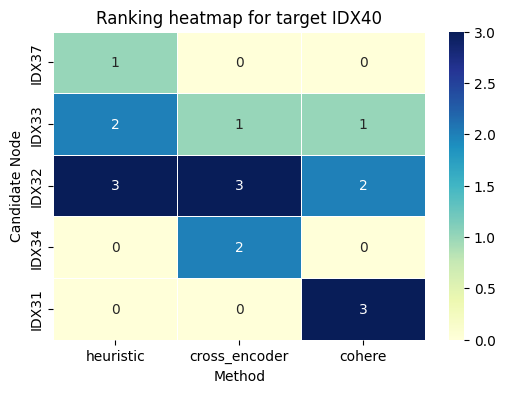

In [8]:
# pip install seaborn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def heatmap_rankings(result):

    rows = {}

    # heuristic
    for rank, item in enumerate(result["heuristic_top"], start=1):
        cid = item["candidate_id"]
        rows.setdefault(cid, {})
        rows[cid]["heuristic"] = rank

    # cross encoder
    for rank, item in enumerate(result["cross_encoder_top"], start=1):
        cid = item["candidate_id"]
        rows.setdefault(cid, {})
        rows[cid]["cross_encoder"] = rank

    # cohere
    for rank, item in enumerate(result["cohere"], start=1):
        cid = item["candidate_id"]
        rows.setdefault(cid, {})
        rows[cid]["cohere"] = rank

    df = pd.DataFrame(rows).T
    df = df.fillna(0)

    plt.figure(figsize=(6,4))
    sns.heatmap(df, annot=True, cmap="YlGnBu", linewidths=0.5)
    plt.title(f"Ranking heatmap for target {result['target_id']}")
    plt.xlabel("Method")
    plt.ylabel("Candidate Node")
    plt.show()

heatmap_rankings(comparison)

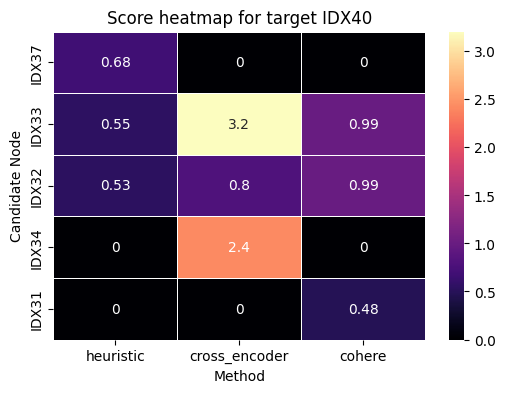

In [9]:
def heatmap_scores(result):

    rows = {}

    for item in result["heuristic_top"]:
        cid = item["candidate_id"]
        rows.setdefault(cid, {})
        rows[cid]["heuristic"] = item["score"]

    for item in result["cross_encoder_top"]:
        cid = item["candidate_id"]
        rows.setdefault(cid, {})
        rows[cid]["cross_encoder"] = item["score"]

    for item in result["cohere"]:
        cid = item["candidate_id"]
        rows.setdefault(cid, {})
        rows[cid]["cohere"] = item["score"]

    df = pd.DataFrame(rows).T
    df = df.fillna(0)

    plt.figure(figsize=(6,4))
    sns.heatmap(df, annot=True, cmap="magma", linewidths=0.5)
    plt.title(f"Score heatmap for target {result['target_id']}")
    plt.xlabel("Method")
    plt.ylabel("Candidate Node")
    plt.show()

heatmap_scores(comparison)